In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler , StandardScaler
from sklearn.model_selection import train_test_split , GridSearchCV

In [5]:
df = pd.read_csv('C:\\Users\\veena\\CloudxLabs\\Kaggle\\Datasets\\AlzheimersPrediction\\alzheimers_prediction_dataset.csv')
df


,Country,Age,Gender,Education Level,BMI,Physical Activity Level,Smoking Status,Alcohol Consumption,Diabetes,Hypertension,...,Dietary Habits,Air Pollution Exposure,Employment Status,Marital Status,Genetic Risk Factor (APOE-ε4 allele),Social Engagement Level,Income Level,Stress Levels,Urban vs Rural Living,Alzheimer’s Diagnosis
0,Spain,90,Male,1,33.0,Medium,Never,Occasionally,No,No,...,Healthy,High,Retired,Single,No,Low,Medium,High,Urban,No
1,Argentina,72,Male,7,29.9,Medium,Former,Never,No,No,...,Healthy,Medium,Unemployed,Widowed,No,High,Low,High,Urban,No
2,South Africa,86,Female,19,22.9,High,Current,Occasionally,No,Yes,...,Average,Medium,Employed,Single,No,Low,Medium,High,Rural,No
3,China,53,Male,17,31.2,Low,Never,Regularly,Yes,No,...,Healthy,Medium,Retired,Single,No,High,Medium,Low,Rural,No
4,Sweden,58,Female,3,30.0,High,Former,Never,Yes,No,...,Unhealthy,High,Employed,Married,No,Low,Medium,High,Rural,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74278,Russia,60,Female,3,22.6,High,Former,Never,No,No,...,Average,High,Unemployed,Widowed,No,Medium,High,Medium,Rural,No
74279,UK,58,Male,18,30.6,Low,Never,Occasionally,Yes,No,...,Average,Medium,Unemployed,Single,No,Medium,High,High,Rural,No
74280,Spain,57,Female,13,28.2,Medium,Never,Regularly,No,No,...,Healthy,Low,Employed,Single,Yes,High,Low,Low,Rural,No
74281,Brazil,73,Female,7,29.0,Low,Never,Regularly,No,No,...,Healthy,Low,Employed,Widowed,No,Low,Low,High,Rural,No


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74283 entries, 0 to 74282
Data columns (total 25 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Country                               74283 non-null  object 
 1   Age                                   74283 non-null  int64  
 2   Gender                                74283 non-null  object 
 3   Education Level                       74283 non-null  int64  
 4   BMI                                   74283 non-null  float64
 5   Physical Activity Level               74283 non-null  object 
 6   Smoking Status                        74283 non-null  object 
 7   Alcohol Consumption                   74283 non-null  object 
 8   Diabetes                              74283 non-null  object 
 9   Hypertension                          74283 non-null  object 
 10  Cholesterol Level                     74283 non-null  object 
 11  Family History 

In [7]:
df.duplicated().sum()

0

In [8]:
num_col = [i for i in df.columns if df[i].dtypes != 'object']

cat_col = [i for i in df.columns if df[i].dtypes == 'object'] 

In [9]:
num_col

['Age', 'Education Level', 'BMI', 'Cognitive Test Score']

In [10]:
cat_col

['Country',
 'Gender',
 'Physical Activity Level',
 'Smoking Status',
 'Alcohol Consumption',
 'Diabetes',
 'Hypertension',
 'Cholesterol Level',
 'Family History of Alzheimer’s',
 'Depression Level',
 'Sleep Quality',
 'Dietary Habits',
 'Air Pollution Exposure',
 'Employment Status',
 'Marital Status',
 'Genetic Risk Factor (APOE-ε4 allele)',
 'Social Engagement Level',
 'Income Level',
 'Stress Levels',
 'Urban vs Rural Living',
 'Alzheimer’s Diagnosis']

In [11]:
from sklearn.preprocessing import LabelEncoder
for i in cat_col :
    le = LabelEncoder()
    df[i] = le.fit_transform(df[i])

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74283 entries, 0 to 74282
Data columns (total 25 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Country                               74283 non-null  int32  
 1   Age                                   74283 non-null  int64  
 2   Gender                                74283 non-null  int32  
 3   Education Level                       74283 non-null  int64  
 4   BMI                                   74283 non-null  float64
 5   Physical Activity Level               74283 non-null  int32  
 6   Smoking Status                        74283 non-null  int32  
 7   Alcohol Consumption                   74283 non-null  int32  
 8   Diabetes                              74283 non-null  int32  
 9   Hypertension                          74283 non-null  int32  
 10  Cholesterol Level                     74283 non-null  int32  
 11  Family History 

In [13]:
df

,Country,Age,Gender,Education Level,BMI,Physical Activity Level,Smoking Status,Alcohol Consumption,Diabetes,Hypertension,...,Dietary Habits,Air Pollution Exposure,Employment Status,Marital Status,Genetic Risk Factor (APOE-ε4 allele),Social Engagement Level,Income Level,Stress Levels,Urban vs Rural Living,Alzheimer’s Diagnosis
0,16,90,1,1,33.0,2,2,1,0,0,...,1,0,1,1,0,1,2,0,1,0
1,0,72,1,7,29.9,2,1,0,0,0,...,1,2,2,2,0,0,1,0,1,0
2,14,86,0,19,22.9,0,0,1,0,1,...,0,2,0,1,0,1,2,0,0,0
3,4,53,1,17,31.2,1,2,2,1,0,...,1,2,1,1,0,0,2,1,0,0
4,17,58,0,3,30.0,0,1,0,1,0,...,2,0,0,0,0,1,2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74278,12,60,0,3,22.6,0,1,0,0,0,...,0,0,2,2,0,2,0,2,0,0
74279,18,58,1,18,30.6,1,2,1,1,0,...,0,2,2,1,0,2,0,0,0,0
74280,16,57,0,13,28.2,2,2,2,0,0,...,1,1,0,1,1,0,1,1,0,0
74281,2,73,0,7,29.0,1,2,2,0,0,...,1,1,0,2,0,1,1,0,0,0


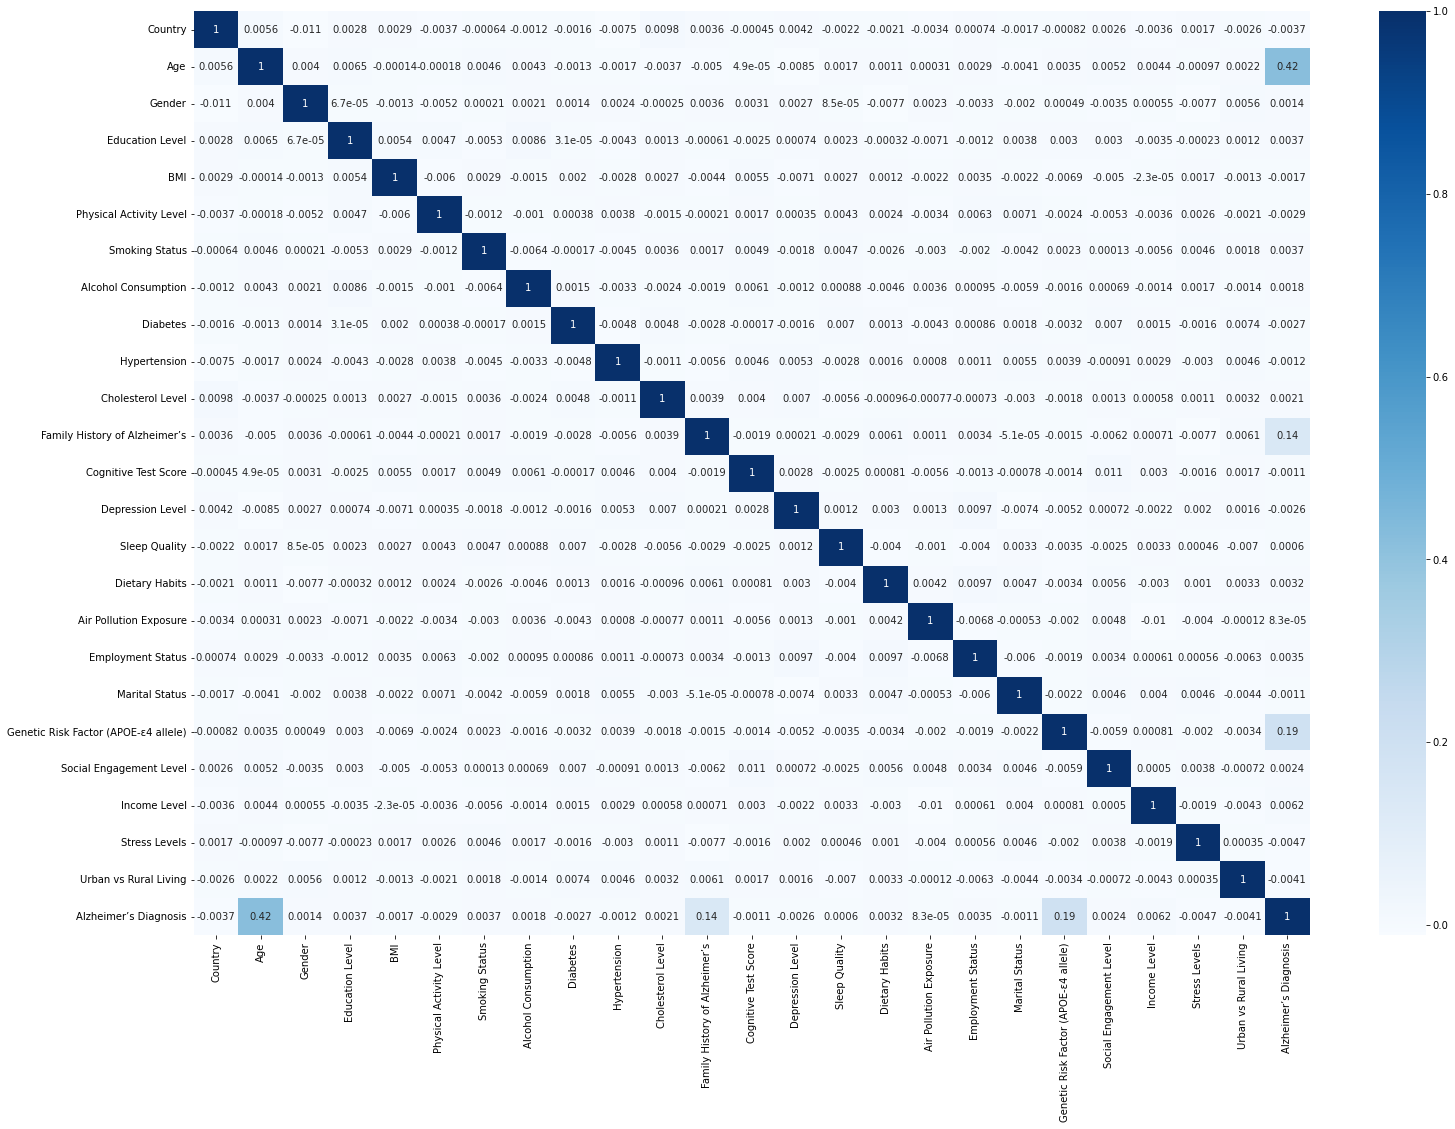

In [16]:
correlation_matrix =df.corr()
plt.figure(figsize=(25,17))
sns.heatmap(correlation_matrix , annot= True , cmap='Blues')
plt.show()

In [21]:
y = df['Alzheimer’s Diagnosis']
X_orig = df.drop(columns=['Alzheimer’s Diagnosis'])

In [24]:
scaler = MinMaxScaler()
X = scaler.fit_transform(X_orig)

In [26]:
x_train , x_test , y_train , y_test = train_test_split(X,y ,train_size=0.8,shuffle=True,random_state=40)

In [34]:
x_train.shape

(59426, 24)

In [35]:
x_test.shape

(14857, 24)

In [36]:
import tensorflow as tf
assert tf.__version__ >= "2.0"

In [37]:
from tensorflow import keras

In [72]:
keras.backend.clear_session() # clearing session
np.random.seed(42) # generating random see
tf.random.set_seed(42) # set.seed function helps reuse same set of random variables

In [73]:
model = keras.models.Sequential([
    keras.layers.Dense(x_train.shape[1],input_shape= (x_train.shape[1],)), # input layer
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid") #output layer
])


In [74]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 24)                600       
                                                                 
 dense_1 (Dense)             (None, 300)               7500      
                                                                 
 dense_2 (Dense)             (None, 100)               30100     
                                                                 
 dense_3 (Dense)             (None, 1)                 101       
                                                                 
Total params: 38,301
Trainable params: 38,301
Non-trainable params: 0
_________________________________________________________________


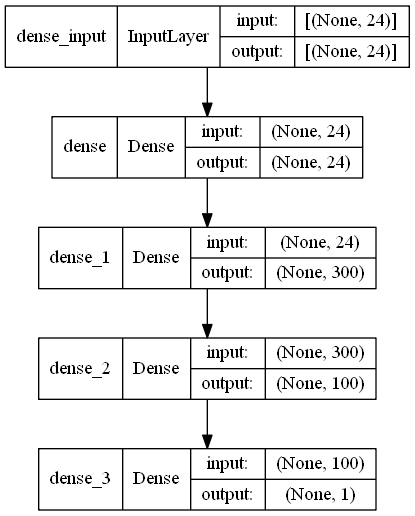

In [75]:
keras.utils.plot_model(model, "my_alzheimersPred.png", show_shapes=True)

In [76]:
sgd = keras.optimizers.SGD(learning_rate=0.01)
# Compiling the model we created

model.compile(loss="binary_crossentropy",
              optimizer=sgd,
              metrics=["accuracy"])

In [77]:
# Train the model
history = model.fit(x_train, y_train, epochs=40, validation_split=0.2)

Epoch 1/40
1486/1486 [==============================] - 2s 1ms/step - loss: 0.6402 - accuracy: 0.6303 - val_loss: 0.5923 - val_accuracy: 0.6760
Epoch 2/40
1486/1486 [==============================] - 2s 1ms/step - loss: 0.5661 - accuracy: 0.6988 - val_loss: 0.5518 - val_accuracy: 0.7106
Epoch 3/40
1486/1486 [==============================] - 2s 1ms/step - loss: 0.5535 - accuracy: 0.7086 - val_loss: 0.5485 - val_accuracy: 0.7124
Epoch 4/40
1486/1486 [==============================] - 2s 1ms/step - loss: 0.5521 - accuracy: 0.7111 - val_loss: 0.5489 - val_accuracy: 0.7083
Epoch 5/40
1486/1486 [==============================] - 2s 1ms/step - loss: 0.5515 - accuracy: 0.7108 - val_loss: 0.5481 - val_accuracy: 0.7093
Epoch 6/40
1486/1486 [==============================] - 2s 1ms/step - loss: 0.5506 - accuracy: 0.7112 - val_loss: 0.5474 - val_accuracy: 0.7115
Epoch 7/40
1486/1486 [==============================] - 2s 1ms/step - loss: 0.5502 - accuracy: 0.7096 - val_loss: 0.5540 - val_accuracy:

In [78]:
history.params # getting the param history

{'verbose': 1, 'epochs': 40, 'steps': 1486}

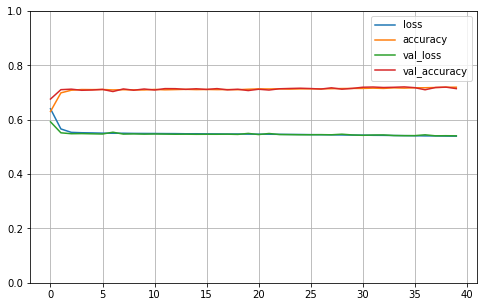

In [79]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # setting limits for y-axis
plt.show()

In [80]:
# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')

465/465 [==============================] - 0s 679us/step - loss: 0.5392 - accuracy: 0.7139
Test Loss: 0.5392066836357117
Test Accuracy: 71.39%


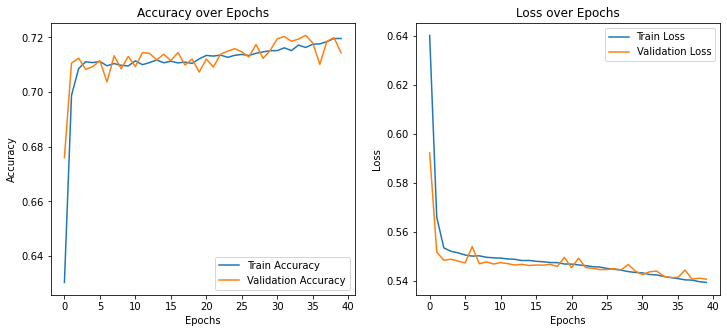

In [82]:
# Plot the accuracy and loss
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()